# Brain Age Prediction with a Hybrid CNN + Vision Transformer

Walkthrough notebook building a hybrid CNN + 3D Vision Transformer for predicting brain age from structural MRI, developed during a research internship at USC Viterbi (IUSSTF-Viterbi Fellowship). Trained on UK Biobank structural MRI volumes.

**Note:** the dataset (UK Biobank scans and labels) is not included in this repository - only the model architecture, training loop, and this walkthrough. Training logs below are from an intermediate run kept for illustration; see model.py and run_experiments.py for the final, configurable training pipeline used for the full hyperparameter sweep.

In [1]:
import torch
import torch.nn as nn
import torchvision.transforms as T
from torch.optim import Adam
from torch.utils.data import DataLoader
import numpy as np

# Patch Embeddings

In [2]:
class PatchEmbedding(nn.Module):
  def __init__(self, d_model, img_size, patch_size, n_channels):
    super().__init__()

    self.d_model = d_model # Dimensionality of Model
    self.img_size = img_size # Image Size
    self.patch_size = patch_size # Patch Size
    self.n_channels = n_channels # Number of Channels

    self.linear_project = nn.Conv3d(self.n_channels, self.d_model, kernel_size=self.patch_size, stride=self.patch_size)

  # B: Batch Size
  # C: Image Channels
  # H: Image Height
  # W: Image Width
  # P_col: Patch Column
  # P_row: Patch Row
  def forward(self, x):
    x = self.linear_project(x) # (B, C, H, W) -> (B, d_model, P_col, P_row)

    x = x.flatten(2) # (B, d_model, P_col, P_row) -> (B, d_model, P)

    x = x.transpose(-2, -1) # (B, d_model, P) -> (B, P, d_model)

    return x

# Class Token and Positional Encoding

In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_seq_length=512):
        super().__init__()
        self.d_model = d_model
        self.max_seq_length = max_seq_length

        # [1, max_seq_length, d_model]
        pe = torch.zeros(max_seq_length, d_model)
        for pos in range(max_seq_length):
            for i in range(d_model):
                if i % 2 == 0:
                    pe[pos][i] = np.sin(pos / (10000 ** (i / d_model)))
                else:
                    pe[pos][i] = np.cos(pos / (10000 ** ((i - 1) / d_model)))
        self.register_buffer("pe_base", pe.unsqueeze(0))  # shape: [1, max_len, d_model]

        self.cls_token = nn.Parameter(torch.randn(1, 1, d_model))  # shape: [1, 1, d_model]

    def forward(self, x):
        B, P, D = x.shape  # Batch size, Patch tokens, d_model
        x = torch.cat((self.cls_token.expand(B, -1, -1), x), dim=1)  # Add CLS: [B, P+1, D]

        seq_len = x.size(1)
        if seq_len > self.pe_base.size(1):
            # Interpolate positional encoding to required length
            pe = F.interpolate(
                self.pe_base.permute(0, 2, 1),  # (1, d_model, seq_len)
                size=seq_len,
                mode='linear',
                align_corners=False
            ).permute(0, 2, 1)  # back to (1, seq_len, d_model)
        else:
            pe = self.pe_base[:, :seq_len, :]  # Crop

        return x + pe


# Multi-Head Attention

In [5]:
class AttentionHead(nn.Module):
  def __init__(self, d_model, head_size):
    super().__init__()
    self.head_size = head_size

    self.query = nn.Linear(d_model, head_size)
    self.key = nn.Linear(d_model, head_size)
    self.value = nn.Linear(d_model, head_size)

  def forward(self, x):
    # Obtaining Queries, Keys, and Values
    Q = self.query(x)
    K = self.key(x)
    V = self.value(x)

    # Dot Product of Queries and Keys
    attention = Q @ K.transpose(-2,-1)

    # Scaling
    attention = attention / (self.head_size ** 0.5)

    attention = torch.softmax(attention, dim=-1)

    attention = attention @ V

    return attention

In [6]:
class MultiHeadAttention(nn.Module):
  def __init__(self, d_model, n_heads):
    super().__init__()
    self.head_size = d_model // n_heads

    self.W_o = nn.Linear(d_model, d_model)

    self.heads = nn.ModuleList([AttentionHead(d_model, self.head_size) for _ in range(n_heads)])

  def forward(self, x):
    # Combine attention heads
    out = torch.cat([head(x) for head in self.heads], dim=-1)

    out = self.W_o(out)

    return out

# Transformer Encoder

In [7]:
class TransformerEncoder(nn.Module):
  def __init__(self, d_model, n_heads, r_mlp=4, dropout=0.3):
    super().__init__()
    self.d_model = d_model
    self.n_heads = n_heads

    # Sub-Layer 1 Normalization
    self.ln1 = nn.LayerNorm(d_model)

    # Multi-Head Attention
    self.mha = MultiHeadAttention(d_model, n_heads)

    # Dropout Layer
    self.dropout = nn.Dropout(dropout)

    # Sub-Layer 2 Normalization
    self.ln2 = nn.LayerNorm(d_model)

    # Multilayer Perception
    self.mlp = nn.Sequential(
        nn.Linear(d_model, d_model*r_mlp),
        nn.GELU(),
        nn.Dropout(dropout),
        nn.Linear(d_model*r_mlp, d_model),
        nn.Dropout(dropout)
    )

  def forward(self, x):
    # Residual Connection After Sub-Layer 1
    out = x + self.dropout(self.mha(self.ln1(x))) 

    # Residual Connection After Sub-Layer 2
    out = out + self.mlp(self.ln2(out))

    return out

# Vision Transformer Model

In [ ]:
class VisionTransformer(nn.Module):
  def __init__(self, d_model, n_classes, img_size, patch_size, n_channels, n_heads, n_layers, dropout=0.3):
    super().__init__()

    assert img_size[0] % patch_size[0] == 0 and img_size[1] % patch_size[1] == 0 and img_size[2] % patch_size[2] == 0, "img_size dimensions must be divisible by patch_size dimensions"
    assert d_model % n_heads == 0, "d_model must be divisible by n_heads"

    self.d_model = d_model # Dimensionality of model
    self.n_classes = n_classes # Number of classes
    self.img_size = img_size # Image size
    self.patch_size = patch_size # Patch size
    self.n_channels = n_channels # Number of channels
    self.n_heads = n_heads # Number of attention heads
    # CNN Stem for local feature extraction
    self.cnn_stem = nn.Sequential(
    nn.Conv3d(n_channels, 8, kernel_size=3, padding=1),
    nn.BatchNorm3d(8),  # or nn.InstanceNorm3d(8, affine=True)
    nn.ReLU(inplace=True),

    nn.Conv3d(8, 16, kernel_size=3, padding=1),
    nn.BatchNorm3d(16),
    nn.ReLU(inplace=True),

    nn.Conv3d(16, 32, kernel_size=3, padding=1),
    nn.BatchNorm3d(32),
    nn.ReLU(inplace=True),

    nn.Conv3d(32, 64, kernel_size=3, padding=1),
    nn.BatchNorm3d(64),
    nn.ReLU(inplace=True),
)
    # Updated image size and channels after CNN
    cnn_output_shape = tuple(s // 2 for s in img_size)  # Due to stride=2 in the second Conv3d layer
    cnn_channels_out = 64  # Output channels after CNN

    self.n_patches = (cnn_output_shape[0] * cnn_output_shape[1] * cnn_output_shape[2]) // (self.patch_size[0] * self.patch_size[1] * self.patch_size[2])
    self.max_seq_length = self.n_patches + 1

    self.patch_embedding = PatchEmbedding(self.d_model, cnn_output_shape, self.patch_size, cnn_channels_out)
    self.positional_encoding = PositionalEncoding( self.d_model, self.max_seq_length)
    self.transformer_encoder = nn.Sequential(*[TransformerEncoder( self.d_model, self.n_heads) for _ in range(n_layers)])

    self.dropout = nn.Dropout(dropout)

    # Classification Regression Layer
    self.classifier = nn.Linear(self.d_model, 1)

  def forward(self, images):

    x = self.cnn_stem(images) # Apply CNN stem to extract local features

    x = self.patch_embedding(x)

    x = self.positional_encoding(x)

    x = self.transformer_encoder(x)

    x = self.dropout(x[:,0]) # Only the class token

    x = self.classifier(x)

    return x

# Training Parameters

In [ ]:
d_model = 64
n_classes = 1
img_size = (128,128,128)
patch_size = (8,8,8)
n_channels = 1
n_heads = 4
n_layers = 16
batch_size = 4
epochs = 100
alpha = 0.0025 # 0.0005

# Load Brain Dataset

In [11]:
import nibabel as nib
from torch.utils.data import Dataset, DataLoader, random_split
import torch
import os
import pandas as pd

class PreloadedBrainDataset(Dataset):
    def __init__(self, root_dir, label_csv, transform=None):
        self.samples = []  # List of (img_tensor, age_tensor, subject_id)
        self.transform = transform

        df = pd.read_csv(label_csv)
        label_map = dict(zip(df['Participant ID'].astype(str),
                             df['Age when attended assessment centre | Instance 2']))

        file_list = [f for f in os.listdir(root_dir) if f.endswith(".nii.gz")]
        for file_name in file_list:
            file_path = os.path.join(root_dir, file_name)
            subject_id = file_name.split("_")[0]
            age = label_map.get(subject_id, -1)

            if age == -1:
                continue  # Skip missing labels

            # Load image
            img = nib.load(file_path).get_fdata()
            img = torch.tensor(img, dtype=torch.float32).unsqueeze(0)  # Add channel dim
            img = (img - img.min()) / (img.max() - img.min() + 1e-5)

            self.samples.append((img, torch.tensor(age, dtype=torch.float32), subject_id))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        return self.samples[idx]


In [12]:
label_csv_path = "Age_Acq_merged.csv"

full_dataset = PreloadedBrainDataset(
    root_dir="./downsampled",
    label_csv=label_csv_path
)

# 70% train, 10% val, 20% test
total_size = len(full_dataset)
train_size = int(0.7 * total_size)
val_size = int(0.1 * total_size)
test_size = total_size - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(
    full_dataset, [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(42)
)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)


/tmp/ipykernel_2576332/4189960097.py:12: DtypeWarning: Columns (4,6,7) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(label_csv)


# Training and Validation

In [ ]:
#!/usr/bin/env python3
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import nibabel as nib
from torch.utils.data import Dataset, DataLoader, random_split
from torch.optim import Adam
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.nn import MSELoss
import pandas as pd
import os

# ===========================
# Patch Embedding
# ===========================
class PatchEmbedding(nn.Module):
    def __init__(self, d_model, img_size, patch_size, n_channels):
        super().__init__()
        self.linear_project = nn.Conv3d(n_channels, d_model, kernel_size=patch_size, stride=patch_size)

    def forward(self, x):
        x = self.linear_project(x)
        x = x.flatten(2).transpose(-2, -1)
        return x

# ===========================
# Positional Encoding
# ===========================
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_seq_length=512):
        super().__init__()
        pe = torch.zeros(max_seq_length, d_model)
        for pos in range(max_seq_length):
            for i in range(d_model):
                if i % 2 == 0:
                    pe[pos][i] = np.sin(pos / (10000 ** (i / d_model)))
                else:
                    pe[pos][i] = np.cos(pos / (10000 ** ((i - 1) / d_model)))
        self.register_buffer("pe_base", pe.unsqueeze(0))
        self.cls_token = nn.Parameter(torch.randn(1, 1, d_model))

    def forward(self, x):
        B, P, D = x.shape
        x = torch.cat((self.cls_token.expand(B, -1, -1), x), dim=1)
        pe = self.pe_base[:, :x.size(1), :]
        return x + pe

# ===========================
# Attention Blocks
# ===========================
class AttentionHead(nn.Module):
    def __init__(self, d_model, head_size):
        super().__init__()
        self.query = nn.Linear(d_model, head_size)
        self.key = nn.Linear(d_model, head_size)
        self.value = nn.Linear(d_model, head_size)
        self.scale = head_size ** 0.5

    def forward(self, x):
        Q, K, V = self.query(x), self.key(x), self.value(x)
        attn = (Q @ K.transpose(-2, -1)) / self.scale
        attn = torch.softmax(attn, dim=-1)
        return attn @ V

class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, n_heads):
        super().__init__()
        head_size = d_model // n_heads
        self.heads = nn.ModuleList([AttentionHead(d_model, head_size) for _ in range(n_heads)])
        self.W_o = nn.Linear(d_model, d_model)

    def forward(self, x):
        out = torch.cat([h(x) for h in self.heads], dim=-1)
        return self.W_o(out)

class TransformerEncoder(nn.Module):
    def __init__(self, d_model, n_heads, r_mlp=4, dropout=0.3):
        super().__init__()
        self.ln1 = nn.LayerNorm(d_model)
        self.mha = MultiHeadAttention(d_model, n_heads)
        self.dropout = nn.Dropout(dropout)
        self.ln2 = nn.LayerNorm(d_model)
        self.mlp = nn.Sequential(
            nn.Linear(d_model, d_model*r_mlp),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_model*r_mlp, d_model),
            nn.Dropout(dropout)
        )

    def forward(self, x):
        x = x + self.dropout(self.mha(self.ln1(x)))
        x = x + self.mlp(self.ln2(x))
        return x

# ===========================
# Vision Transformer Model
# ===========================
class VisionTransformer(nn.Module):
    def __init__(self, d_model, n_classes, img_size, patch_size, n_channels, n_heads, n_layers, dropout=0.3):
        super().__init__()
        self.cnn_stem = nn.Sequential(
            nn.Conv3d(n_channels, 8, kernel_size=3, padding=1),
            nn.BatchNorm3d(8),
            nn.ReLU(inplace=True),
            nn.Conv3d(8, 16, kernel_size=3, padding=1),
            nn.BatchNorm3d(16),
            nn.ReLU(inplace=True),
            nn.Conv3d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm3d(32),
            nn.ReLU(inplace=True),
            nn.Conv3d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm3d(64),
            nn.ReLU(inplace=True),
        )
        cnn_output_shape = tuple(s // 2 for s in img_size)
        cnn_channels_out = 64
        self.patch_embedding = PatchEmbedding(d_model, cnn_output_shape, patch_size, cnn_channels_out)
        n_patches = (cnn_output_shape[0]*cnn_output_shape[1]*cnn_output_shape[2]) // (patch_size[0]*patch_size[1]*patch_size[2])
        self.positional_encoding = PositionalEncoding(d_model, n_patches+1)
        self.transformer_encoder = nn.Sequential(*[TransformerEncoder(d_model, n_heads) for _ in range(n_layers)])
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(d_model, 1)

    def forward(self, x):
        x = self.cnn_stem(x)
        x = self.patch_embedding(x)
        x = self.positional_encoding(x)
        x = self.transformer_encoder(x)
        x = self.dropout(x[:, 0])
        return self.classifier(x)

# ===========================
# Dataset
# ===========================
class PreloadedBrainDataset(Dataset):
    def __init__(self, root_dir, label_csv):
        self.samples = []
        df = pd.read_csv(label_csv)
        label_map = dict(zip(df['Participant ID'].astype(str),
                             df['Age when attended assessment centre | Instance 2']))
        for fname in os.listdir(root_dir):
            if fname.endswith(".nii.gz"):
                sid = fname.split("_")[0]
                if sid not in label_map: continue
                age = label_map[sid]
                img = nib.load(os.path.join(root_dir, fname)).get_fdata()
                img = torch.tensor(img, dtype=torch.float32).unsqueeze(0)
                img = (img - img.min()) / (img.max() - img.min() + 1e-5)
                self.samples.append((img, torch.tensor(age, dtype=torch.float32), sid))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        return self.samples[idx]

# ===========================
# Training Script
# ===========================
def main():
    label_csv_path = "Age_Acq_merged.csv"
    full_dataset = PreloadedBrainDataset(root_dir="./downsampled", label_csv=label_csv_path)

    d_model = 64
    n_classes = 1
    img_size = (128,128,128)
    patch_size = (8,8,8)
    n_channels = 1
    n_heads = 4
    n_layers = 16
    batch_size = 4
    epochs = 100
    alpha = 0.0025

    train_size = int(0.7 * len(full_dataset))
    val_size = int(0.1 * len(full_dataset))
    test_size = len(full_dataset) - train_size - val_size

    train_dataset, val_dataset, test_dataset = random_split(
        full_dataset, [train_size, val_size, test_size],
        generator=torch.Generator().manual_seed(42)
    )

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader   = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print("Using device:", device, f"({torch.cuda.get_device_name(device)})" if torch.cuda.is_available() else "")

    transformer = VisionTransformer(d_model, n_classes, img_size, patch_size, n_channels, n_heads, n_layers).to(device)
    optimizer = Adam(transformer.parameters(), lr=alpha, weight_decay=1e-5)
    criterion = MSELoss()
    scheduler = CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-6)

    train_losses, val_losses = [], []
    train_maes, val_maes = [], []
    lrs = []

    checkpoint_dir = "checkpoints_hybrid_modif_8_cosanlr_DP0.3_100epochs_bs4"
    os.makedirs(checkpoint_dir, exist_ok=True)

    for epoch in range(epochs):
        transformer.train()
        train_loss, total_abs_error, total_samples = 0.0, 0.0, 0
        for inputs, labels, _ in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = transformer(inputs).squeeze(1)
            loss = criterion(outputs, labels.float())
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
            total_abs_error += torch.sum(torch.abs(outputs - labels)).item()
            total_samples += labels.size(0)

        avg_train_loss = train_loss / len(train_loader)
        avg_train_mae = total_abs_error / total_samples
        train_losses.append(avg_train_loss)
        train_maes.append(avg_train_mae)

        transformer.eval()
        val_loss, val_abs_error, val_samples = 0.0, 0.0, 0
        with torch.no_grad():
            for inputs, labels, _ in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = transformer(inputs).squeeze(1)
                loss = criterion(outputs, labels.float())
                val_loss += loss.item()
                val_abs_error += torch.sum(torch.abs(outputs - labels)).item()
                val_samples += labels.size(0)

        avg_val_loss = val_loss / len(val_loader)
        avg_val_mae = val_abs_error / val_samples
        val_losses.append(avg_val_loss)
        val_maes.append(avg_val_mae)

        scheduler.step()
        current_lr = optimizer.param_groups[0]['lr']
        lrs.append(current_lr)

        torch.save(transformer.state_dict(), f"{checkpoint_dir}/checkpoint_epoch_{epoch+1}.pth")

        print(f"Epoch {epoch+1}/{epochs} | Train MSE: {avg_train_loss:.4f}, MAE: {avg_train_mae:.2f} | "
              f"Val MSE: {avg_val_loss:.4f}, MAE: {avg_val_mae:.2f} | LR: {current_lr:.12f}")

    df = pd.DataFrame({
        "epoch": list(range(1, len(train_losses) + 1)),
        "train_mse": train_losses,
        "val_mse": val_losses,
        "train_mae": train_maes,
        "val_mae": val_maes,
        "current_lr": lrs
    })
    df.to_csv("epoch_metrics_hybrid_modif_8_cosanlr_DP0.3_100epochs_bs4.csv", index=False)
    print("Saved metrics to 'epoch_metrics_hybrid_modif_8_cosanlr_DP0.3_100epochs_bs4.csv'")

if __name__ == "__main__":
    main()


Using device: cuda (NVIDIA A100 80GB PCIe)
Epoch 1/100 | Train MSE: 162.5566, MAE: 9.96 | Val MSE: 55.6329, MAE: 5.98 | LR: 0.002499383447
Epoch 2/100 | Train MSE: 129.0657, MAE: 9.18 | Val MSE: 55.2138, MAE: 5.99 | LR: 0.002497534397
Epoch 3/100 | Train MSE: 126.0239, MAE: 9.08 | Val MSE: 77.7555, MAE: 7.43 | LR: 0.002494454675
Epoch 4/100 | Train MSE: 110.7933, MAE: 8.46 | Val MSE: 57.7810, MAE: 6.07 | LR: 0.002490147319
Epoch 5/100 | Train MSE: 121.7055, MAE: 8.91 | Val MSE: 72.8196, MAE: 6.76 | LR: 0.002484616582
Epoch 6/100 | Train MSE: 106.6889, MAE: 8.42 | Val MSE: 81.6826, MAE: 7.17 | LR: 0.002477867920
Epoch 7/100 | Train MSE: 107.7500, MAE: 8.41 | Val MSE: 73.8246, MAE: 6.81 | LR: 0.002469907994
Epoch 8/100 | Train MSE: 109.1032, MAE: 8.46 | Val MSE: 75.0641, MAE: 7.28 | LR: 0.002460744660
Epoch 9/100 | Train MSE: 105.1690, MAE: 8.21 | Val MSE: 70.9156, MAE: 7.05 | LR: 0.002450386960
Epoch 10/100 | Train MSE: 107.8466, MAE: 8.36 | Val MSE: 55.9092, MAE: 5.99 | LR: 0.002438845

In [ ]:
print("Last learning rate:", optimizer.param_groups[0]['lr'])   

Last learning rate: 5.000000000000002e-09


In [ ]:
import matplotlib.pyplot as plt
from torch.nn import MSELoss
import numpy as np
import os
import torch
from torch.optim import Adam
from torch.optim.lr_scheduler import CosineAnnealingLR

# --- Setup device ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device, f"({torch.cuda.get_device_name(device)})" if torch.cuda.is_available() else "")

# --- Recreate model ---
transformer = VisionTransformer(d_model, n_classes, img_size, patch_size, n_channels, n_heads, n_layers).to(device)

# --- Optimizer & Scheduler ---
optimizer = Adam(transformer.parameters(), lr=alpha, weight_decay=1e-5)
criterion = MSELoss()
scheduler = CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-6)

# --- Paths ---
checkpoint_dir = "checkpoints_hybrid_modif_8_cosanlr_DP0.3_100epochs_bs4"
os.makedirs(checkpoint_dir, exist_ok=True)

# --- Resume from checkpoint ---
start_epoch = 44
checkpoint_path = os.path.join(checkpoint_dir, f"checkpoint_epoch_{start_epoch}.pth")
transformer.load_state_dict(torch.load(checkpoint_path, map_location=device))
print(f"Loaded model weights from epoch {start_epoch}")

# Optionally set LR to last used value (if you have it logged)
# optimizer.param_groups[0]['lr'] = <last_lr_value>

# --- Training loop ---
for epoch in range(start_epoch, epochs):
    ### TRAIN ###
    transformer.train()
    train_loss = 0.0
    total_abs_error = 0.0
    total_samples = 0

    for inputs, labels, _ in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = transformer(inputs).squeeze(1)
        loss = criterion(outputs, labels.float())
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
        total_abs_error += torch.sum(torch.abs(outputs - labels)).item()
        total_samples += labels.size(0)

    avg_train_loss = train_loss / len(train_loader)
    avg_train_mae = total_abs_error / total_samples

    ### VALIDATION ###
    transformer.eval()
    val_loss = 0.0
    val_abs_error = 0.0
    val_samples = 0

    with torch.no_grad():
        for inputs, labels, _ in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = transformer(inputs).squeeze(1)
            loss = criterion(outputs, labels.float())
            val_loss += loss.item()
            val_abs_error += torch.sum(torch.abs(outputs - labels)).item()
            val_samples += labels.size(0)

    avg_val_loss = val_loss / len(val_loader)
    avg_val_mae = val_abs_error / val_samples

    # Step scheduler
    scheduler.step()

    # Current LR
    current_lr = optimizer.param_groups[0]['lr']

    # Save checkpoint
    torch.save(transformer.state_dict(),
               os.path.join(checkpoint_dir, f"checkpoint_epoch_{epoch+1}.pth"))

    print(f"Epoch {epoch+1}/{epochs} | "
          f"Train MSE: {avg_train_loss:.4f}, MAE: {avg_train_mae:.2f} | "
          f"Val MSE: {avg_val_loss:.4f}, MAE: {avg_val_mae:.2f} | "
          f"LR: {current_lr:.12f}")


Using device: cuda (NVIDIA A100 80GB PCIe)
Loaded model weights from epoch 44
Epoch 45/100 | Train MSE: 61.2555, MAE: 6.35 | Val MSE: 43.1113, MAE: 5.37 | LR: 0.001484266911
Epoch 46/100 | Train MSE: 59.9966, MAE: 6.19 | Val MSE: 45.1994, MAE: 5.50 | LR: 0.001483169148
Epoch 47/100 | Train MSE: 63.4356, MAE: 6.34 | Val MSE: 39.9947, MAE: 5.06 | LR: 0.001481340745
Epoch 48/100 | Train MSE: 57.9630, MAE: 6.09 | Val MSE: 40.5880, MAE: 5.18 | LR: 0.001478783509
Epoch 49/100 | Train MSE: 58.5357, MAE: 6.12 | Val MSE: 40.8460, MAE: 5.04 | LR: 0.001475499961
Epoch 50/100 | Train MSE: 58.3031, MAE: 6.16 | Val MSE: 45.5514, MAE: 5.66 | LR: 0.001471493344
Epoch 51/100 | Train MSE: 58.6815, MAE: 6.05 | Val MSE: 48.8227, MAE: 5.71 | LR: 0.001466767610
Epoch 52/100 | Train MSE: 57.3938, MAE: 6.05 | Val MSE: 44.8327, MAE: 5.26 | LR: 0.001461327424
Epoch 53/100 | Train MSE: 55.7171, MAE: 5.95 | Val MSE: 45.0057, MAE: 5.33 | LR: 0.001455178155
Epoch 54/100 | Train MSE: 54.6387, MAE: 5.93 | Val MSE: 52

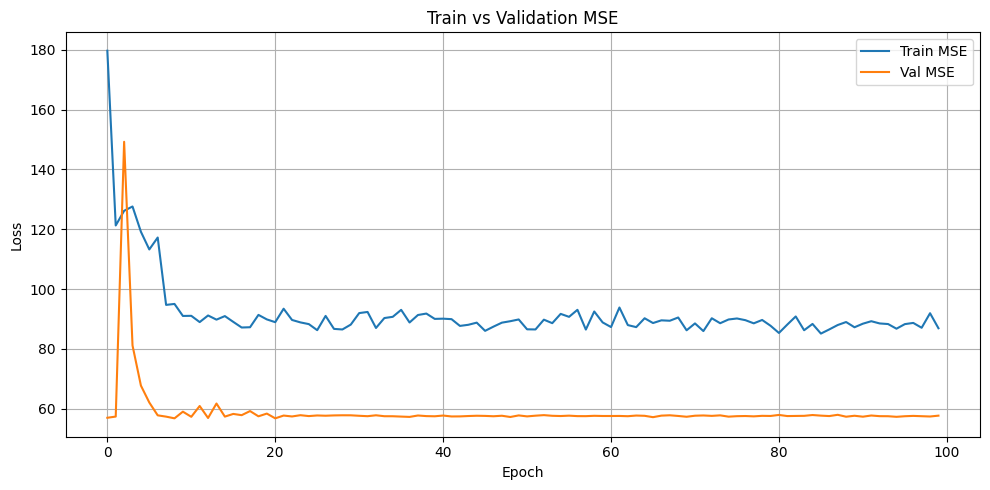

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(train_losses, label="Train MSE")
plt.plot(val_losses, label="Val MSE")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Train vs Validation MSE")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# Testing